# Creating a simple linear BMI calculator workflow
- Its a non LLM based workflow
- 4 nodes
    - Input = height, weight
    - Calculation 
    - Based on BMI value classify as obese or healthy
    - Output
- State
    - Height
    - Weight
    - BMI value
    - Category
- START, END are the dummy nodes that are used to indicate the start and the end of the graph

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# Define the State
- State will be of type type dict or pydantic

In [14]:
from unicodedata import category


class BMIState(TypedDict):
    height: float
    weight: float
    bmi: float
    category: str



# Define the graph
- You need to create a graph object which is of type StateGraph
- Add nodes to the graph
- You also need to pass the state to the node
- Add edges
- Compile the graph
- Execute the graph

In [15]:
# Define the graph
graph = StateGraph(BMIState)


# Function defination for BMI calculation
- As this function will be executed by the node, the input to this node will be a state which will be of type BMIState and will also return a state which will be of type BMIState
- The weight and the height input values can be fetched from the state
- And the final output must also be stored back in the state

In [16]:
def calculate_bmi(state: BMIState) -> BMIState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state


# Function defination for classfying the category based on BMI value

In [17]:
def classify_category(state: BMIState) -> BMIState:
    if state["bmi"] > 30:
        state["category"] = "Obese"
    else:
        state["category"] = "Healthy"
    return state


# Add nodes to the graph
- Syntax:
    - `graph.add_node(Name of the Node, Function Name)`

In [18]:
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("classify_category", classify_category)

# Add edges
- Start Node -> calculate_bmi Node -> classify_category Node -> End Node
- Totally 3 edges i.e.
    - START Node -> calculate_bmi Node
    - calculate_bmi Node -> classify_category Node
    - classify_category Node -> END Node
- Syntax
    - `graph.add_edge(Node1, Node2)`

In [19]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "classify_category")
graph.add_edge("classify_category", END)


# Compile Graph

In [20]:
workflow = graph.compile()

# Execute the Graph
- Syntax
    - `workflow.invoke(initial_state)`
- This will also return a state

In [21]:
initial_state = {"height": 170, "weight": 70}
final_state = workflow.invoke(initial_state)
print(final_state)

{'height': 170, 'weight': 70, 'bmi': 0.002422145328719723, 'category': 'Healthy'}


# View the graph visually 
1. Print workflow
2. Using IPython.display

## Option 1: Printing workflow

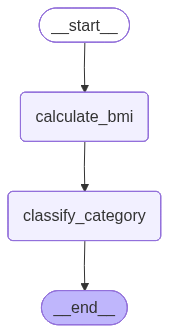

In [22]:
workflow

## Option 2: Using IPython.display

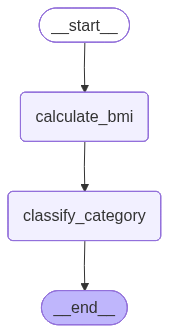

In [23]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))